In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!pip install mne

Mounted at /content/drive


 Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking local storage...
Copying Train and Eval data safely to Colab Local Storage...
Copying Data to SSD:   1%|          | 9/1679 [00:06<22:11,  1.25file/s]
Detected Drive disconnection. Attempting to remount...
Copying Data to SSD:   1%|          | 10/1679 [00:46<5:59:53, 12.94s/file]Mounted at /content/drive
Drive remounted successfully.

Copying Data to SSD:  42%|████▏     | 709/1679 [08:11<11:47,  1.37file/s]
Detected Drive disconnection. Attempting to remount...
Copying Data to SSD:  42%|████▏     | 710/1679 [08:46<2:56:58, 10.96s/file]Mounted at /content/drive
Drive remounted successfully.

Copying Data to SSD: 100%|██████████| 1679/1679 [18:18<00:00,  1.53file/s]

Data successfully copied to local storage!

Loading Patient Paths from /content/local_dataset...
Found 1400 Train patients.
Found 276 Eval (Test) patients.

STAGE 1: Training TCN using Dat

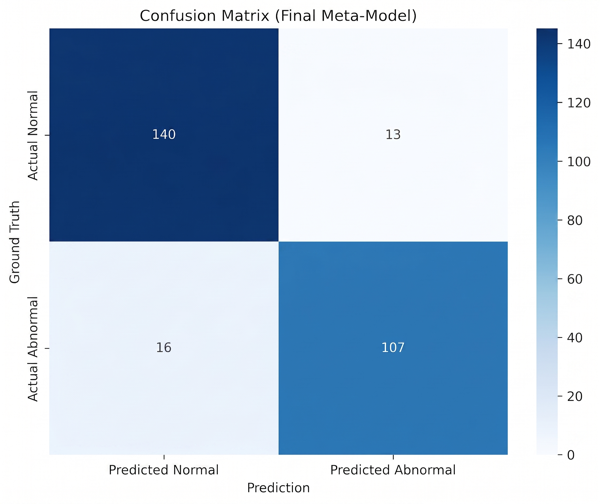

In [ ]:
import os
import shutil
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import gc
import time
from tqdm import tqdm

def force_remount():
    print("\nDetected Drive disconnection. Attempting to remount...")
    try:
        drive.flush_and_unmount()
    except:
        pass
    time.sleep(5)
    drive.mount('/content/drive', force_remount=True)
    print("Drive remounted successfully.\n")

try:
    drive.mount('/content/drive')
except:
    pass

DRIVE_BASE_DIR = '/content/drive/MyDrive/gp_dataset/preprocessing_v2'
MODEL_SAVE_DIR = '/content/drive/MyDrive/models_v2_paper'
LOCAL_BASE_DIR = '/content/local_dataset'

print("Checking local storage...")

def get_total_files(src):
    total = 0
    for root, dirs, files in os.walk(src):
        total += len(files)
    return total

def robust_copy_with_progress(src, dst, pbar):
    if not os.path.exists(dst):
        os.makedirs(dst)

    while True:
        try:
            items = os.listdir(src)
            break
        except OSError as e:
            if "Transport endpoint" in str(e) or "Input/output" in str(e): force_remount()
            else: raise e

    for item in items:
        s = os.path.join(src, item)
        d = os.path.join(dst, item)

        while True:
            try:
                is_dir = os.path.isdir(s)
                break
            except OSError as e:
                if "Transport endpoint" in str(e) or "Input/output" in str(e): force_remount()
                else: raise e

        if is_dir:
            robust_copy_with_progress(s, d, pbar)
        else:
            if not os.path.exists(d):
                copied = False
                while not copied:
                    try:
                        shutil.copy2(s, d)
                        copied = True
                        pbar.update(1)
                    except OSError as e:
                        if "Transport endpoint" in str(e) or "Input/output" in str(e): force_remount()
                        else:
                            print(f"\nSkipped {s} due to error: {e}")
                            break
            else:
                pbar.update(1)
def setup_local_data():
    train_local = os.path.join(LOCAL_BASE_DIR, 'train')
    eval_local = os.path.join(LOCAL_BASE_DIR, 'eval')

    if not os.path.exists(train_local) or not os.path.exists(eval_local):
        print("Copying Train and Eval data safely to Colab Local Storage...")
        total_files = get_total_files(DRIVE_BASE_DIR)

        with tqdm(total=total_files, desc="Copying Data to SSD", unit="file") as pbar:
            robust_copy_with_progress(DRIVE_BASE_DIR, LOCAL_BASE_DIR, pbar)

        print("\nData successfully copied to local storage!")
    else:
        print("Train and Eval Data are already perfectly in local storage.")

    return LOCAL_BASE_DIR

ACTIVE_BASE_DIR = setup_local_data()

INPUT_SHAPE = (19, 6000)
MAX_WINDOWS = 20

def build_tcn_first_stage():
    inputs = layers.Input(shape=INPUT_SHAPE)
    x = layers.Permute((2, 1))(inputs)

    num_filters = 64
    for dilation_rate in [1, 2, 4, 8, 16]:
        residual = x
        x = layers.Conv1D(filters=num_filters, kernel_size=3, padding='causal',
                          dilation_rate=dilation_rate, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)

        if residual.shape[-1] != num_filters:
            residual = layers.Conv1D(num_filters, 1, padding='same')(residual)
        x = layers.Add()([x, residual])

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs, name="TCN_Window_Model")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

print(f"\nLoading Patient Paths from {ACTIVE_BASE_DIR}...")
train_patients = []
test_patients = []

for cls_name, label in [('normal', 0), ('abnormal', 1)]:
    dir_path = os.path.join(ACTIVE_BASE_DIR, 'train', cls_name)
    if os.path.exists(dir_path):
        for f in sorted(os.listdir(dir_path)):
            if f.endswith('.npy'): train_patients.append((os.path.join(dir_path, f), label))

for cls_name, label in [('normal', 0), ('abnormal', 1)]:
    dir_path = os.path.join(ACTIVE_BASE_DIR, 'eval', cls_name)
    if os.path.exists(dir_path):
        for f in sorted(os.listdir(dir_path)):
            if f.endswith('.npy'): test_patients.append((os.path.join(dir_path, f), label))

print(f"Found {len(train_patients)} Train patients.")
print(f"Found {len(test_patients)} Eval (Test) patients.")

tcn_train_patients, tcn_val_patients = train_test_split(
    train_patients, test_size=0.1, random_state=42, stratify=[p[1] for p in train_patients]
)

def window_generator(patient_list, shuffle_patients=True):
    local_list = patient_list.copy()
    if shuffle_patients: np.random.shuffle(local_list)
    for path, label in local_list:
        try:
            windows = np.load(path)
            for w in windows: yield w, label
            del windows
        except: continue

def create_tf_dataset(patient_list, batch_size=32, shuffle=True):
    ds = tf.data.Dataset.from_generator(
        lambda: window_generator(patient_list, shuffle),
        output_signature=(tf.TensorSpec(shape=INPUT_SHAPE, dtype=tf.float32), tf.TensorSpec(shape=(), dtype=tf.int32))
    )
    if shuffle: ds = ds.shuffle(buffer_size=1000)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print(f"\nSTAGE 1: Training TCN using Data Generators...")
train_ds = create_tf_dataset(tcn_train_patients, batch_size=32, shuffle=True)
val_ds = create_tf_dataset(tcn_val_patients, batch_size=32, shuffle=False)

tcn_model = build_tcn_first_stage()
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(os.path.join(MODEL_SAVE_DIR, 'best_tcn.keras'), save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

tcn_model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=callbacks, verbose=1)

def extract_advanced_features(tcn, windows_array):
    probs = tcn.predict(windows_array, verbose=0).flatten()

    if len(probs) < MAX_WINDOWS:
        raw_probs = np.pad(probs, (0, MAX_WINDOWS - len(probs)), 'constant')
    else:
        raw_probs = probs[:MAX_WINDOWS]

    if len(probs) > 0:
        f_max = np.max(probs)
        f_mean = np.mean(probs)
        f_std = np.std(probs)
        f_median = np.median(probs)
    else:
        f_max = f_mean = f_std = f_median = 0.0

    return np.concatenate([[f_max, f_mean, f_std, f_median], raw_probs])

print("\nSTAGE 2: Extracting ADVANCED Meta-Features for XGBoost...")
X_meta_train, y_meta_train = [], []
for path, label in tqdm(train_patients, desc="Extracting Train Features"):
    try:
        windows = np.load(path)
        X_meta_train.append(extract_advanced_features(tcn_model, windows))
        y_meta_train.append(label)
        del windows
    except: continue

X_meta_test, y_meta_test = [], []
for path, label in tqdm(test_patients, desc="Extracting Eval Features"):
    try:
        windows = np.load(path)
        X_meta_test.append(extract_advanced_features(tcn_model, windows))
        y_meta_test.append(label)
        del windows
    except: continue

print("\nTraining XGBoost Meta-Model Arbitrator...")
xgb_model = xgb.XGBClassifier(
    max_depth=4,
    learning_rate=0.01,
    n_estimators=800,
    eval_metric='auc',
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(np.array(X_meta_train), np.array(y_meta_train))
xgb_model.save_model(os.path.join(MODEL_SAVE_DIR, 'xgboost_meta_model.json'))

print("\n" + "="*60)
print("TRUE CLINICAL EVALUATION (DEFAULT THRESHOLD 0.5)")
print("="*60)

y_pred = xgb_model.predict(np.array(X_meta_test))
y_proba = xgb_model.predict_proba(np.array(X_meta_test))[:, 1]

print(f"Final True Accuracy:  {accuracy_score(y_meta_test, y_pred) * 100:.2f}%")
print(f"Final True ROC AUC:   {roc_auc_score(y_meta_test, y_proba):.4f}\n")

print("Detailed Classification Report:\n")
print(classification_report(y_meta_test, y_pred, target_names=['Normal (0)', 'Abnormal (1)']))

cm = confusion_matrix(y_meta_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Abnormal'],
            yticklabels=['Actual Normal', 'Actual Abnormal'])
plt.title('Confusion Matrix (Final Meta-Model)')
plt.xlabel('Prediction')
plt.ylabel('Ground Truth')

cm_path = os.path.join(MODEL_SAVE_DIR, 'confusion_matrix_final.png')
plt.savefig(cm_path, bbox_inches='tight', dpi=300)
plt.show()
